In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
pd.options.mode.chained_assignment = None


# sctrial: Stress Test and Scalability Analysis

**Objective:** Benchmarking `sctrial` performance on genome-wide analysis of a large biological dataset.


## 1. Load and Construct Data


In [2]:
import scanpy as sc
import pandas as pd
import numpy as np
import sctrial as st
import time
import matplotlib.pyplot as plt

adata = sc.datasets.pbmc3k_processed()
np.random.seed(42)
donors = [f"D{i}" for i in range(20)]
adata.obs['donor'] = np.random.choice(donors, size=adata.n_obs)
adata.obs['visit'] = np.random.choice(['V1', 'V2'], size=adata.n_obs)
adata.obs['arm'] = np.where(adata.obs['donor'].isin(donors[:10]), 'Treated', 'Control')
adata.obs['cell_type'] = adata.obs['louvain']

c = adata.obs.groupby(['donor', 'visit'], observed=True).size().unstack(fill_value=0)
keep = c[(c.get('V1',0)>0) & (c.get('V2',0)>0)].index
adata = adata[adata.obs['donor'].isin(keep)].copy()
adata.layers['log1p'] = adata.X.copy()
print(f"Stress dataset: {adata.n_obs} cells, {adata.n_vars} genes")


Stress dataset: 2638 cells, 1838 genes


## 2. Genome-Wide DiD Benchmarking


In [3]:
design = st.TrialDesign(participant_col="donor", visit_col="visit", arm_col="arm", 
                        arm_treated="Treated", arm_control="Control", celltype_col="cell_type")
start = time.time()
res = st.did_table(adata, features=adata.var_names[:2000], design=design, visits=("V1", "V2"), aggregate="participant_visit")
print(f"Genome-wide DiD (2000 genes) took {time.time() - start:.2f} seconds.")


Genome-wide DiD (2000 genes) took 5.03 seconds.


## 3. Abundance Shifting


In [4]:
ab_res = st.abundance_did(adata, design, visits=('V1', 'V2'))
if not ab_res.empty: display(ab_res.set_index('celltype'))


,n_participants,beta_DiD,se_DiD,p_DiD,beta_time,p_time,FDR_DiD
celltype,,,,,,,
Dendritic cells,7,0.074372,0.018848,0.010894,-0.030815,0.054658,0.076260
B cells,20,0.035792,0.043913,0.425688,-0.032867,0.303839,0.878029
CD14+ Monocytes,20,-0.028019,0.035786,0.443832,-0.005058,0.843821,0.878029
FCGR3A+ Monocytes,20,-0.022258,0.032843,0.506585,0.011222,0.634759,0.878029
CD4 T cells,20,-0.011259,0.030825,0.719169,0.047103,0.044416,0.878029
CD8 T cells,20,-0.013893,0.043405,0.752596,-0.015847,0.611918,0.878029
NK cells,20,0.005921,0.039354,0.882087,-0.008345,0.767714,0.882087


## 4. Large-Scale GSEA Benchmark


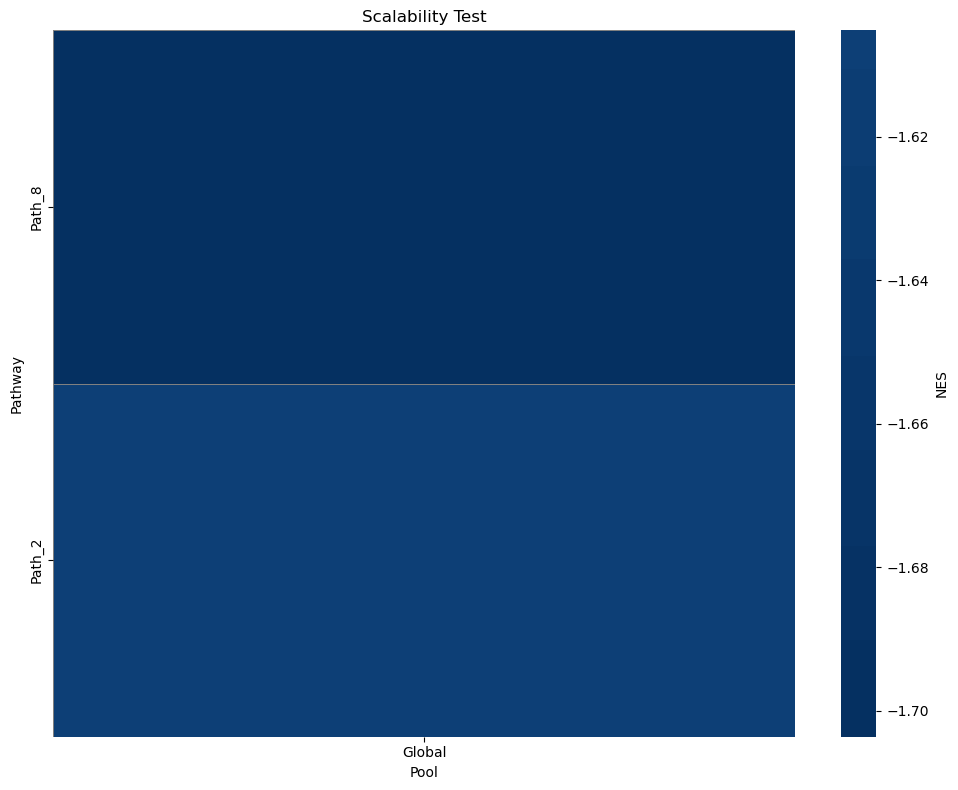

In [5]:
gene_sets = {f"Path_{i}": adata.var_names[np.random.randint(0, 500, 10)].tolist() for i in range(15)}
try:
    g_res = st.run_gsea_did(adata, gene_sets=gene_sets, design=design, visits=('V1', 'V2'), min_size=1)
    st.plot_gsea_heatmap(g_res, title="Scalability Test", figsize=(10, 8))
    plt.show()
except Exception as e: print(f"GSEA failed: {e}")


## 5. Global Statistical Visualization


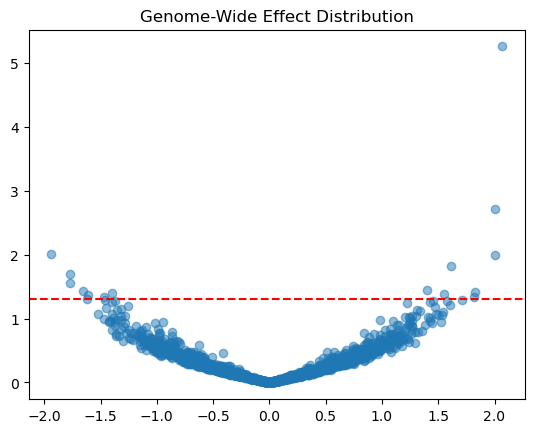

In [6]:
from sctrial.plotting import did_volcano_frame
v = did_volcano_frame(res)
plt.scatter(v['beta_DiD'], v['neglog10p'], alpha=0.5)
plt.axhline(-np.log10(0.05), color='red', linestyle='--')
plt.title("Genome-Wide Effect Distribution")
plt.show()
